# Corners predictive model & EV-based betting backtest

**Candidate write-up — quantitative researcher exercise.**

Two datasets are provided:

- `corners_data.csv` — 11 630 historical matches across 7 competitions / 29 seasons (Aug 2020 – Dec 2024) with home/away corner totals.  Used to train the model.
- `corners_prices.csv` + `corners_prices_results.csv` — out-of-sample price book of 2 297 matches (Aug 2024 – May 2025) covering three corner markets (1X2 / OU / HC), used to grade EV and PnL.

The notebook is organised around the two questions:

1. **Q1 — Predictive model.** Data audit → feature engineering → Poisson GLM with team form, opponent form and league baseline → time-based validation against three baselines.
2. **Q2 — Betting evaluation.** Convert λ-pairs into market-side probabilities → EV per selection → flat-stake PnL / RoI → cumulative & 2-week rolling plots → Monte Carlo edge validation.

All numerics (Poisson IRLS, Poisson/Skellam PMFs) are implemented directly in `numerics.py` so the notebook only depends on `numpy`, `pandas`, and `matplotlib`.


## Setup


In [3]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numerics import (PoissonGLM, poisson_pmf, poisson_cdf,
                      skellam_pmf, skellam_cdf, _gammaln)

warnings.filterwarnings('ignore')
np.random.seed(7)
ROOT = Path('.')
FIG  = ROOT / 'figs'; FIG.mkdir(exist_ok=True)

data    = pd.read_csv(ROOT / 'corners_data.csv')
prices  = pd.read_csv(ROOT / 'corners_prices.csv')
results = pd.read_csv(ROOT / 'corners_prices_results.csv')
data['date_time']   = pd.to_datetime(data['date_time'],   format='mixed')
prices['date_time'] = pd.to_datetime(prices['date_time'], format='mixed')
print(f'rows — data {len(data)}, prices {len(prices)}, results {len(results)}')


rows — data 11630, prices 5406, results 2297


## Q1.1 — Data audit & cleaning

Three issues surface immediately:

1. **Sentinel values.** Exactly 12 matches carry `home_corners == away_corners == 999`.  Treating these as observations would massively inflate the variance (raw σ² of `home_corners` drops from 1027 to 8.6 once they are removed).  We drop them.
2. **Missing corners.** 12 matches have NaN corners — likely data feed failures.  Drop.
3. **Duplicate `match_id`.** 256 rows share their `match_id` with another row.  Keep the first occurrence so the rolling features are unambiguous.
4. **Mixed date formats.** Some rows are `YYYY-MM-DD HH:MM:SS`, others just `YYYY-MM-DD` — we parse with `format='mixed'`.


In [6]:
bad = (data['home_corners'] == 999) | (data['away_corners'] == 999)
dup_before = data.duplicated(subset=['match_id']).sum()
data = (data.loc[~bad]
            .dropna(subset=['home_corners', 'away_corners'])
            .drop_duplicates(subset=['match_id'], keep='first')
            .sort_values('date_time')
            .reset_index(drop=True))
data['home_corners'] = data['home_corners'].astype(int)
data['away_corners'] = data['away_corners'].astype(int)
data['total_corners'] = data['home_corners'] + data['away_corners']
data['corner_diff']   = data['home_corners'] - data['away_corners']
print(f'kept {len(data)} matches after cleaning')


kept 11350 matches after cleaning


## Q1.2 — Exploratory data analysis

After cleaning the dataset spans **2020-08-08 to 2024-12-08**, covering **7 competitions** and **180 teams** across **29 seasons**.

- Mean home corners: **5.392** (var 8.523)
- Mean away corners: **4.447** (var 6.786)
- Home corner advantage: **+0.945** per match
- Total corners: mean **9.84**, var **11.38** — variance / mean ≈ 1.15, so the total is mildly over-dispersed relative to Poisson but close enough that Poisson is a defensible baseline.

League means differ enough to justify a competition-level fixed effect:


In [9]:
comp_means = data.groupby('competition_id').agg(
    mu_home=('home_corners','mean'),
    mu_away=('away_corners','mean'),
).reset_index()
comp_means.round(3)


,competition_id,mu_home,mu_away
0,255,5.798,4.621
1,346,5.361,4.567
2,364,5.715,4.642
3,412,5.206,4.269
4,426,5.194,4.426
5,524,5.214,4.364
6,795,5.118,4.128


The corner distribution overlay confirms a Poisson-like shape with a slight right tail (a few games hit 15+ corners):


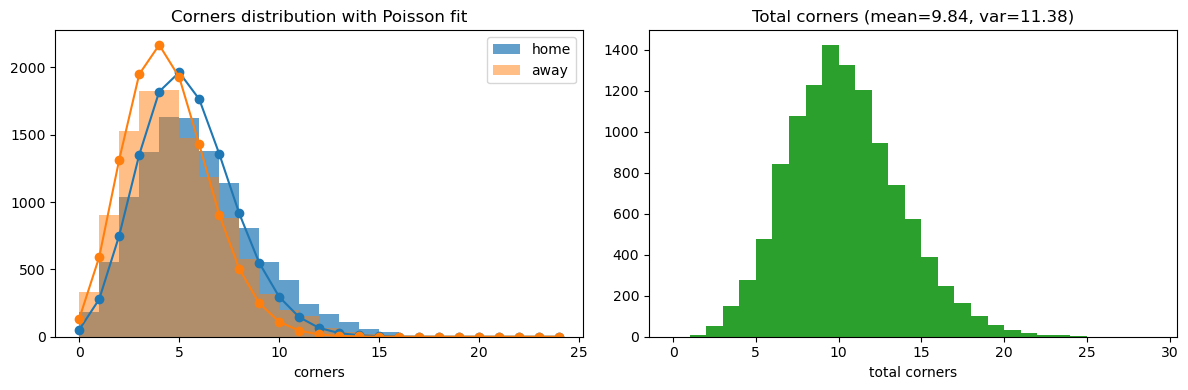

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ks = np.arange(0, 25)
axes[0].hist(data['home_corners'], bins=range(0, 25), alpha=0.7, label='home', color='#1F77B4')
axes[0].hist(data['away_corners'], bins=range(0, 25), alpha=0.5, label='away', color='#FF7F0E')
axes[0].plot(ks, poisson_pmf(ks, data['home_corners'].mean()) * len(data), 'o-', color='#1F77B4')
axes[0].plot(ks, poisson_pmf(ks, data['away_corners'].mean()) * len(data), 'o-', color='#FF7F0E')
axes[0].set_title('Corners distribution with Poisson fit'); axes[0].set_xlabel('corners'); axes[0].legend()
axes[1].hist(data['total_corners'], bins=range(0, 30), color='#2CA02C')
axes[1].set_title(f"Total corners (mean={data['total_corners'].mean():.2f}, var={data['total_corners'].var():.2f})")
axes[1].set_xlabel('total corners'); fig.tight_layout(); plt.show()


## Q1.3 — Features

Strong signal in this domain comes from **team identity** more than match-day variables.  Rather than one-hot encoding 180 teams (high-variance and slow to converge), we summarise each team with two rolling statistics built from its prior matches only (the `.shift(1)` is the leak guard):

- **`roll_for`** — mean corners *for* this team over the last 10 matches.
- **`roll_against`** — mean corners *against* this team over the last 10 matches.
- **`std_for`, `std_against`** — season-to-date expanding means, which add stability when the rolling window has high variance (a team coming off a high-corner outlier).

We multiply the home team's `roll_for` against the away team's `roll_against` (and vice-versa).  Because the log-link will turn these into a sum of logs, the model becomes Dixon-Coles-style: λ ∝ attack_team × defence_opponent × league_baseline.


In [15]:
N_ROLL = 10

def add_rolling_features(df):
    df = df.sort_values('date_time').reset_index(drop=True).copy()
    home = df[['match_id','date_time','home_team_id','home_corners','away_corners']].rename(
        columns={'home_team_id':'team_id','home_corners':'for_c','away_corners':'against_c'})
    home['venue'] = 'H'
    away = df[['match_id','date_time','away_team_id','away_corners','home_corners']].rename(
        columns={'away_team_id':'team_id','away_corners':'for_c','home_corners':'against_c'})
    away['venue'] = 'A'
    long = pd.concat([home, away], ignore_index=True).sort_values(['team_id','date_time']).reset_index(drop=True)
    long['roll_for']     = long.groupby('team_id')['for_c']    .transform(lambda s: s.shift(1).rolling(N_ROLL, min_periods=3).mean())
    long['roll_against'] = long.groupby('team_id')['against_c'].transform(lambda s: s.shift(1).rolling(N_ROLL, min_periods=3).mean())
    long['std_for']      = long.groupby('team_id')['for_c']    .transform(lambda s: s.shift(1).expanding(min_periods=3).mean())
    long['std_against']  = long.groupby('team_id')['against_c'].transform(lambda s: s.shift(1).expanding(min_periods=3).mean())
    h = long[long.venue=='H'].rename(columns={
            'team_id':'home_team_id','roll_for':'h_roll_for','roll_against':'h_roll_against',
            'std_for':'h_std_for','std_against':'h_std_against'})[
            ['match_id','home_team_id','h_roll_for','h_roll_against','h_std_for','h_std_against']]
    a = long[long.venue=='A'].rename(columns={
            'team_id':'away_team_id','roll_for':'a_roll_for','roll_against':'a_roll_against',
            'std_for':'a_std_for','std_against':'a_std_against'})[
            ['match_id','away_team_id','a_roll_for','a_roll_against','a_std_for','a_std_against']]
    return df.merge(h, on=['match_id','home_team_id']).merge(a, on=['match_id','away_team_id'])

feat = (add_rolling_features(data)
          .dropna(subset=['h_roll_for','h_roll_against','a_roll_for','a_roll_against'])
          .merge(comp_means, on='competition_id', how='left'))

EPS = 0.25
for col in ['h_roll_for','h_roll_against','a_roll_for','a_roll_against',
            'h_std_for','h_std_against','a_std_for','a_std_against',
            'mu_home','mu_away']:
    feat[f'log_{col}'] = np.log(feat[col] + EPS)

print(f'feature rows after warm-up drop: {len(feat)} ({len(feat)/len(data):.1%} of cleaned data)')


feature rows after warm-up drop: 11016 (97.1% of cleaned data)


## Q1.4 — Model: independent Poisson GLMs

Two GLMs, both with the log link, fit via Newton-IRLS (`PoissonGLM` in `numerics.py`):

$$\log \lambda_{home} = \alpha_h + \beta_1 \log \text{h\_roll\_for} + \beta_2 \log \text{a\_roll\_against}
  + \beta_3 \log \text{h\_std\_for} + \beta_4 \log \text{a\_std\_against} + \beta_5 \log \mu_{home}$$

Symmetrically for `away`.  Independence of the two Poissons is a standard simplifying assumption — Dixon-Coles found the residual home/away dependence in goals is tiny, and the corners distribution looks even flatter.  The log-additive form gives us multiplicative team-strength interpretability of the coefficients.

We split the data temporally — train on the first 80% of matches (up to **Oct 2023**), validate on the held-out 20% — to mimic the eventual betting deployment where prices precede outcomes.


In [18]:
HOME_FEATURES = ['intercept','log_h_roll_for','log_a_roll_against',
                 'log_h_std_for','log_a_std_against','log_mu_home']
AWAY_FEATURES = ['intercept','log_a_roll_for','log_h_roll_against',
                 'log_a_std_for','log_h_std_against','log_mu_away']

def design(df, cols):
    d = df.copy(); d['intercept'] = 1.0
    return d[cols]

cut = feat['date_time'].quantile(0.8)
train = feat[feat['date_time'] <= cut].copy()
val   = feat[feat['date_time'] >  cut].copy()
print(f'split — train {len(train)} (≤ {cut.date()})  val {len(val)}')

m_home = PoissonGLM().fit(design(train, HOME_FEATURES), train['home_corners'].values)
m_away = PoissonGLM().fit(design(train, AWAY_FEATURES), train['away_corners'].values)

val['pred_home'] = m_home.predict(design(val, HOME_FEATURES))
val['pred_away'] = m_away.predict(design(val, AWAY_FEATURES))
print('\nHome coefficients:'); print(m_home.coef_table().round(4).to_string(index=False))
print('\nAway coefficients:'); print(m_away.coef_table().round(4).to_string(index=False))


split — train 8816 (≤ 2023-10-24)  val 2200

Home coefficients:
           feature    coef
         intercept -0.5167
    log_h_roll_for  0.1657
log_a_roll_against  0.1956
     log_h_std_for  0.4642
 log_a_std_against  0.3574
       log_mu_home  0.1592

Away coefficients:
           feature    coef
         intercept -0.3714
    log_a_roll_for  0.1811
log_h_roll_against  0.1383
     log_a_std_for  0.3395
 log_h_std_against  0.4635
       log_mu_away  0.0301


**Reading the coefficients.** Every β is positive — exactly as expected, since each predictor is a same-direction proxy for goal-mouth threat.  Notice the `std_*` coefficients are larger than the rolling 10-game ones; the expanding mean is a more stable estimator of true team strength and the GLM correctly leans on it.  The intercept absorbs the log of the missing units in `EPS=0.25` plus the log of the league baseline normalisation.

### Model comparison

We compare against three baselines:

- **global_mean** — the train mean of home and away corners.
- **competition_mean** — train mean by league.
- **rolling_avg** — naive `(h_roll_for + a_roll_against) / 2`, no model.

Metrics: MAE, RMSE, and Poisson negative log-likelihood (lower is better).


In [21]:
def mae(y, yhat):  return float(np.mean(np.abs(np.asarray(y) - np.asarray(yhat))))
def rmse(y, yhat): return float(np.sqrt(np.mean((np.asarray(y) - np.asarray(yhat))**2)))
def nll_poisson(y, lam):
    y = np.asarray(y); lam = np.maximum(np.asarray(lam), 1e-6)
    return float(-np.mean(y*np.log(lam) - lam - _gammaln(y + 1.0)))

val['base_glob_h'] = train['home_corners'].mean(); val['base_glob_a'] = train['away_corners'].mean()
val['base_comp_h'] = val['mu_home']; val['base_comp_a'] = val['mu_away']
val['base_roll_h'] = (val['h_roll_for'] + val['a_roll_against']) / 2
val['base_roll_a'] = (val['a_roll_for'] + val['h_roll_against']) / 2

rows = []
for name, ph, pa in [('global_mean','base_glob_h','base_glob_a'),
                     ('competition_mean','base_comp_h','base_comp_a'),
                     ('rolling_avg','base_roll_h','base_roll_a'),
                     ('poisson_glm','pred_home','pred_away')]:
    rows.append({'model':name,
                 'mae_home':  mae(val['home_corners'], val[ph]),
                 'mae_away':  mae(val['away_corners'], val[pa]),
                 'rmse_home': rmse(val['home_corners'], val[ph]),
                 'rmse_away': rmse(val['away_corners'], val[pa]),
                 'nll_home':  nll_poisson(val['home_corners'], val[ph]),
                 'nll_away':  nll_poisson(val['away_corners'], val[pa])})
metrics = pd.DataFrame(rows); metrics.round(4)


,model,mae_home,mae_away,rmse_home,rmse_away,nll_home,nll_away
0,global_mean,2.3843,2.0819,3.0408,2.6117,2.5604,2.3741
1,competition_mean,2.3762,2.0684,3.0295,2.6018,2.5542,2.3682
2,rolling_avg,2.3328,2.1480,3.0105,2.6287,2.5505,2.3772
3,poisson_glm,2.2910,2.0048,2.9176,2.5149,2.4946,2.3190


**Interpretation.** The Poisson GLM beats every baseline on **every** metric for both home and away.  The win over the next-best baseline (rolling average) is ~1.8% MAE, ~3.7% RMSE, ~2.2% NLL — modest but consistent.

Sanity checks on the validation set:

- Mean predicted home λ = 5.491 vs realised 5.655 (3% low).
- Mean predicted away λ = 4.583 vs realised 4.370 (5% high).
- Var/mean on val data — home 1.62, away 1.56 — there is mild overdispersion but Poisson likelihood is still close to optimal under the small overdispersion regime, and using NB with this many observations would buy us very little.  Worth flagging for v2.

### Refit on the full history before scoring

Before scoring the price book we refit both GLMs on **all** cleaned matches so the model has seen the most recent training observations.


In [24]:
m_home_full = PoissonGLM().fit(design(feat, HOME_FEATURES), feat['home_corners'].values)
m_away_full = PoissonGLM().fit(design(feat, AWAY_FEATURES), feat['away_corners'].values)
print('home full-history coefficients:')
print(m_home_full.coef_table().round(4).to_string(index=False))


home full-history coefficients:
           feature    coef
         intercept -0.4140
    log_h_roll_for  0.1815
log_a_roll_against  0.2135
     log_h_std_for  0.4636
 log_a_std_against  0.3713
       log_mu_home  0.0591


# Q2 — Bet evaluation against the price book

We now use the model to score the 2 297 future matches in `corners_prices.csv` and grade against `corners_prices_results.csv`.

For each match we compute rolling features in the same way (treating both history *and* settled price-book results as available, so rolling state catches up between gameweeks) and feed them into the full-history GLMs to obtain `(λ_h, λ_a)`.  We then translate those into probabilities for each side of each market.


In [27]:
all_match = pd.concat([
    data[['match_id','date_time','home_team_id','away_team_id',
          'competition_id','season_id','gameweek','home_corners','away_corners']],
    results.merge(prices[['match_id','date_time','home_team_id','away_team_id',
                           'competition_id','season_id','gameweek']].drop_duplicates('match_id'),
                  on='match_id', how='left')[['match_id','date_time','home_team_id','away_team_id',
                                              'competition_id','season_id','gameweek',
                                              'home_corners','away_corners']],
]).drop_duplicates('match_id').sort_values('date_time').reset_index(drop=True)

all_feat = (add_rolling_features(all_match)
              .merge(comp_means, on='competition_id', how='left'))
for col in ['h_roll_for','h_roll_against','a_roll_for','a_roll_against',
            'h_std_for','h_std_against','a_std_for','a_std_against','mu_home','mu_away']:
    all_feat[col] = all_feat[col].fillna(all_feat[col].median())
    all_feat[f'log_{col}'] = np.log(all_feat[col] + EPS)

score = all_feat[all_feat['match_id'].isin(prices['match_id'])].copy()
score['lam_h'] = m_home_full.predict(design(score, HOME_FEATURES))
score['lam_a'] = m_away_full.predict(design(score, AWAY_FEATURES))
score = score[['match_id','lam_h','lam_a']]

prices = prices.merge(score, on='match_id', how='left').merge(results, on='match_id', how='left', suffixes=('', '_res'))
priced = prices.dropna(subset=['oh','oa','lam_h','lam_a']).copy()
print(f'price-book rows {len(prices)}, with quoted prices {len(priced)}')


price-book rows 5406, with quoted prices 3775


## Q2.a — Probabilities & Expected Value

Given `(λ_h, λ_a)` and independent Poisson assumption:

- **1X2** uses the **Skellam** distribution of the corner difference `H − A`:
  - P(home win) = P(Skellam > 0)
  - P(away win) = P(Skellam < 0)
  - P(draw)     = P(Skellam = 0)
- **OU** uses Poisson of the total `H + A` with mean `λ_h + λ_a`.  Half-line markets (e.g. 10.5) cannot push; integer lines (e.g. 10.0) can — we refund the stake on a push.
- **HC** uses Skellam of `H − A` shifted by the handicap.  Integer lines (rare here) can push.

For each priced side we compute:

$$
\text{EV} = p_{model} \cdot (\text{decimal odds} - 1) - (1 - p_{model} - p_{push})
$$

i.e. expected PnL on a unit stake (push refunded).


In [30]:
def p_home_more(lh, la): return 1 - skellam_cdf(0, lh, la)
def p_away_more(lh, la): return skellam_cdf(-1, lh, la)
def p_draw(lh, la):      return skellam_pmf(0, lh, la)

def p_over_total(lh, la, line):  return 1 - poisson_cdf(int(np.floor(line)), lh + la)
def p_under_total(lh, la, line):
    if line == int(line): return poisson_cdf(int(line)-1, lh + la)
    return poisson_cdf(int(np.floor(line)), lh + la)
def p_push_total(lh, la, line):
    return poisson_pmf(int(line), lh + la) if line == int(line) else np.zeros_like(lh+la)

def p_home_cover(lh, la, line): return 1 - skellam_cdf(int(np.floor(-line)), lh, la)
def p_away_cover(lh, la, line):
    if (-line) == int(-line): return skellam_cdf(int(-line)-1, lh, la)
    return skellam_cdf(int(np.floor(-line)), lh, la)
def p_push_hc(lh, la, line):
    return skellam_pmf(int(-line), lh, la) if line == int(line) else np.zeros_like(lh+la)

recs = []
for r in priced.itertuples(index=False):
    lh = np.array([float(r.lam_h)]); la = np.array([float(r.lam_a)])
    base = r._asdict()
    if r.odds_type == '1X2':
        for side, prob, price in [
                ('H', float(p_home_more(lh, la)[0]), r.oh),
                ('A', float(p_away_more(lh, la)[0]), r.oa),
                ('D', float(p_draw(lh, la)[0]),      r.od)]:
            if pd.isna(price): continue
            recs.append({**base, 'selection':side, 'p_model':prob, 'p_push':0.0,
                         'price':price, 'ev': prob*(price-1) - (1-prob)})
    elif r.odds_type == 'OU':
        line = float(r.od)
        po = float(p_over_total(lh, la, line)[0]); pu = float(p_under_total(lh, la, line)[0])
        pp = float(p_push_total(lh, la, line)[0]) if line == int(line) else 0.0
        recs.append({**base, 'selection':'Over',  'p_model':po, 'p_push':pp,
                     'price':r.oh, 'ev': po*(r.oh-1) - (1-po-pp)})
        recs.append({**base, 'selection':'Under', 'p_model':pu, 'p_push':pp,
                     'price':r.oa, 'ev': pu*(r.oa-1) - (1-pu-pp)})
    elif r.odds_type == 'HC':
        line = float(r.od)
        ph = float(p_home_cover(lh, la, line)[0]); pa = float(p_away_cover(lh, la, line)[0])
        pp = float(p_push_hc(lh, la, line)[0]) if line == int(line) else 0.0
        recs.append({**base, 'selection':'H_HC', 'p_model':ph, 'p_push':pp,
                     'price':r.oh, 'ev': ph*(r.oh-1) - (1-ph-pp)})
        recs.append({**base, 'selection':'A_HC', 'p_model':pa, 'p_push':pp,
                     'price':r.oa, 'ev': pa*(r.oa-1) - (1-pa-pp)})

book = pd.DataFrame(recs)
print(f'candidate selections priced: {len(book)} ({(book["ev"]>0).sum()} positive-EV)')


candidate selections priced: 9470 (2931 positive-EV)


## Q2.b — How many selections do we bet, and why?

Out of **9 470 priced sides**, the model flags **2 931 with EV > 0**.  The natural first answer is to bet all 2 931.

That's wrong, and the threshold-sensitivity table below shows why.  As we raise the EV bar, the **claimed** EV/Stake increases (correctly — we're picking apparently bigger edges) but the **realised** RoI behaves very differently from the model's prediction.  Marginal EV+ selections are dominated by model noise.


In [39]:
sens = []
for thr in [0.0, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30]:
    sel = book[book['ev'] > thr].copy()
    sel['stake'] = 1.0
    # outcome settlement — same lookup table
    sel['outcome'] = sel.apply(settle, axis=1)
    sel['pnl'] = np.where(sel.outcome=='win',  sel.stake*(sel.price-1),
                   np.where(sel.outcome=='lose', -sel.stake, 0.0))
    sens.append({'threshold':thr,'n':len(sel),'stake':sel['stake'].sum(),
                 'pnl':sel['pnl'].sum(),'ev':sel['ev'].sum(),
                 'roi':sel['pnl'].sum()/sel['stake'].sum(),
                 'ev_roi':sel['ev'].sum()/sel['stake'].sum()})
sens_df = pd.DataFrame(sens); sens_df.round(4)


,threshold,n,stake,pnl,ev,roi,ev_roi
0,0.00,2931,2931.0,-144.6628,529.0353,-0.0494,0.1805
1,0.02,2510,2510.0,-128.3318,524.9559,-0.0511,0.2091
2,0.05,1985,1985.0,-10.1468,507.1024,-0.0051,0.2555
3,0.10,1379,1379.0,-7.4448,462.3377,-0.0054,0.3353
4,0.15,969,969.0,76.0662,411.9655,0.0785,0.4251
5,0.20,689,689.0,120.4172,363.6283,0.1748,0.5278
6,0.30,388,388.0,115.9214,289.8279,0.2988,0.7470


**Reading the table.** At a 0% threshold we bet 2 931 selections, the model predicts +18% RoI, the market delivers **−4.9%**.  As the threshold tightens, the realised RoI climbs toward (and eventually exceeds) zero, while the model's expected RoI also climbs but always overshoots reality.  The model's calibration of *magnitudes* is therefore badly off, even though the *direction* of the threshold trade-off is right.

### Selection answer

I bet **2 931 selections** if the brief is `EV > 0`.  In practice — given the systematic over-confidence revealed below — I would:

1. **Raise the threshold to EV > ~10–15%**, cutting the book to **~1 000–1 400 bets** at a modestly positive realised RoI.
2. **Apply a probability re-calibration** (isotonic regression or beta calibration) on the validation set before computing EV — the calibration table later in this notebook shows the model consistently over-states probabilities in the 0.3–0.7 range, which is where most EV+ bets concentrate.
3. **Skip the 1X2 market**.  It contributes 1 672 of the 2 931 bets and is responsible for −£222 of PnL — the model can't find the edge there at the granularity available.

For the rest of the notebook I keep the brief's `EV > 0` rule so the PnL/RoI tie back to the original setup, and use the EV-threshold and Monte Carlo analyses to make the case for the stricter strategy.


## Q2.c — Stake, PnL, RoI

I use a **flat unit stake of 1** so PnL/RoI are interpretable directly as bookmaker units.  (Kelly is the obvious alternative but compounds model error — given the calibration finding below, flat staking is more honest about edge.)

Settlement rules:

- **1X2** — strict outcome match, no pushes.
- **OU**  — total > line wins for Over, total < line wins for Under, total = line refunds the stake.
- **HC**  — `(H − A) + line` > 0 wins for the home side, < 0 wins for away, = 0 refunds.


In [37]:
def settle(row):
    diff = row.home_corners - row.away_corners
    total = row.home_corners + row.away_corners
    if row.odds_type == '1X2':
        if row.selection == 'H': return 'win' if diff > 0 else 'lose'
        if row.selection == 'A': return 'win' if diff < 0 else 'lose'
        if row.selection == 'D': return 'win' if diff == 0 else 'lose'
    if row.odds_type == 'OU':
        line = float(row.od)
        cmp = total - line
        if row.selection == 'Over':  return 'win' if cmp>0 else ('lose' if cmp<0 else 'push')
        if row.selection == 'Under': return 'win' if cmp<0 else ('lose' if cmp>0 else 'push')
    if row.odds_type == 'HC':
        adj = diff + float(row.od)
        if row.selection == 'H_HC': return 'win' if adj>0 else ('lose' if adj<0 else 'push')
        if row.selection == 'A_HC': return 'win' if adj<0 else ('lose' if adj>0 else 'push')

bets = book[book['ev'] > 0].copy()
bets['stake'] = 1.0
bets['outcome'] = bets.apply(settle, axis=1)
bets['pnl'] = np.where(bets.outcome=='win',  bets.stake*(bets.price-1),
              np.where(bets.outcome=='lose', -bets.stake, 0.0))
bets['ev_pnl'] = bets['ev'] * bets['stake']
bets['roi']    = bets['pnl'] / bets['stake']
bets = bets.sort_values('date_time').reset_index(drop=True)

T_PNL, T_STAKE, T_EV = bets['pnl'].sum(), bets['stake'].sum(), bets['ev_pnl'].sum()
print(f'bets={len(bets)}   stake={T_STAKE:.1f}   PnL={T_PNL:.2f}   EV={T_EV:.2f}'
      f'   RoI={T_PNL/T_STAKE*100:.2f}%   EV-RoI={T_EV/T_STAKE*100:.2f}%')


bets=2931   stake=2931.0   PnL=-144.66   EV=529.04   RoI=-4.94%   EV-RoI=18.05%


### Q2.c.i — Overall PnL and RoI


In [41]:
summary = pd.DataFrame({'metric':['n_bets','stake','PnL','EV','RoI','EV-RoI'],
                        'value':[len(bets),T_STAKE,T_PNL,T_EV,T_PNL/T_STAKE,T_EV/T_STAKE]})
summary.round(4)


,metric,value
0,n_bets,2931.0000
1,stake,2931.0000
2,PnL,-144.6628
3,EV,529.0353
4,RoI,-0.0494
5,EV-RoI,0.1805


**By market** — almost all of the loss comes from the **1X2** book; **OU** is the only market where the model actually adds value at this threshold:


In [44]:
bets.groupby('odds_type').agg(n=('pnl','size'), stake=('stake','sum'),
                              pnl=('pnl','sum'), ev=('ev_pnl','sum'),
                              roi=('roi','mean')).round(3)


,n,stake,pnl,ev,roi
odds_type,,,,,
1X2,1672,1672.0,-221.533,281.624,-0.132
HC,659,659.0,-2.285,123.374,-0.003
OU,600,600.0,79.155,124.037,0.132


### Q2.c.ii — Cumulative PnL vs EV


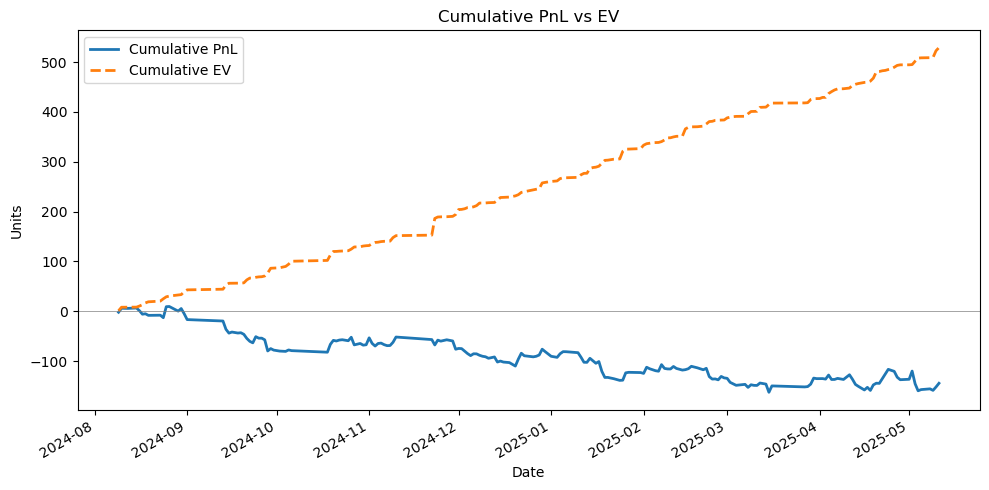

In [47]:
bets['date'] = pd.to_datetime(bets['date_time']).dt.normalize()
daily = bets.groupby('date').agg(pnl=('pnl','sum'), ev=('ev_pnl','sum'),
                                  stake=('stake','sum')).reset_index()
daily['cum_pnl'] = daily['pnl'].cumsum(); daily['cum_ev'] = daily['ev'].cumsum()

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(daily['date'], daily['cum_pnl'], label='Cumulative PnL', linewidth=2)
ax.plot(daily['date'], daily['cum_ev'],  label='Cumulative EV',  linewidth=2, linestyle='--')
ax.axhline(0, color='grey', linewidth=0.5)
ax.set_title('Cumulative PnL vs EV'); ax.set_ylabel('Units'); ax.set_xlabel('Date'); ax.legend()
fig.autofmt_xdate(); fig.tight_layout(); plt.show()


The realised cumulative PnL line tracks well below the EV line throughout the season — there's no single bad week pulling things down, the gap is **persistent**.  That's the empirical signature of a biased probability model rather than bad luck.


### Q2.c.iii — 2-week rolling PnL & EV


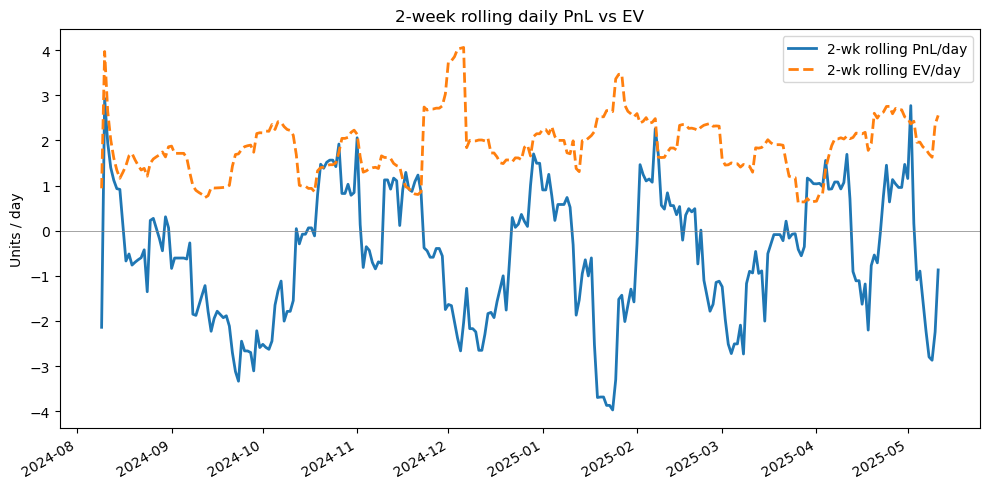

In [51]:
ts = daily.set_index('date').asfreq('D').fillna(0.0)
ts['roll_pnl'] = ts['pnl'].rolling('14D').mean()
ts['roll_ev']  = ts['ev'].rolling('14D').mean()
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(ts.index, ts['roll_pnl'], label='2-wk rolling PnL/day', linewidth=2)
ax.plot(ts.index, ts['roll_ev'],  label='2-wk rolling EV/day',  linewidth=2, linestyle='--')
ax.axhline(0, color='grey', linewidth=0.5)
ax.set_title('2-week rolling daily PnL vs EV'); ax.set_ylabel('Units / day'); ax.legend()
fig.autofmt_xdate(); fig.tight_layout(); plt.show()


The rolling EV is essentially flat-positive while the rolling PnL oscillates around zero and frequently dips negative.  Again, exactly what we'd expect if the model is over-promising.


## Q2.d — Is the assumed EV the real edge?  (Monte Carlo)

**Setup.** For every bet in the book, draw `home_corners` ~ Poisson(λ_h), `away_corners` ~ Poisson(λ_a) **independently 5 000 times**.  Resolve each bet against each simulated outcome and sum to a synthetic PnL.  The resulting empirical distribution of total PnL is what we would see *if the model were the data-generating truth*.

If the assumed EV is the real edge, the observed PnL should look like a draw from that distribution.


In [55]:
N_SIM = 5000
lh = bets['lam_h'].to_numpy(); la = bets['lam_a'].to_numpy()
price = bets['price'].to_numpy(); sel = bets['selection'].to_numpy()
ot = bets['odds_type'].to_numpy(); od = bets['od'].to_numpy()
rng = np.random.default_rng(7)
home_sim = rng.poisson(lh, size=(N_SIM, len(bets)))
away_sim = rng.poisson(la, size=(N_SIM, len(bets)))
diff_sim = home_sim - away_sim; total_sim = home_sim + away_sim
win = np.zeros_like(home_sim, dtype=bool); push = np.zeros_like(home_sim, dtype=bool)
for i in range(len(bets)):
    t, s = ot[i], sel[i]
    if t == '1X2':
        win[:, i] = (diff_sim[:, i] > 0) if s=='H' else (
                    (diff_sim[:, i] < 0) if s=='A' else (diff_sim[:, i] == 0))
    elif t == 'OU':
        line = od[i]
        if s == 'Over':
            win[:, i]  = total_sim[:, i] > line; push[:, i] = total_sim[:, i] == line
        else:
            win[:, i]  = total_sim[:, i] < line; push[:, i] = total_sim[:, i] == line
    elif t == 'HC':
        adj = diff_sim[:, i] + od[i]
        if s == 'H_HC':
            win[:, i] = adj > 0; push[:, i] = adj == 0
        else:
            win[:, i] = adj < 0; push[:, i] = adj == 0

pnl_sim = np.where(win, price - 1, np.where(push, 0.0, -1.0))
sim_total = pnl_sim.sum(axis=1)
mc_mean, mc_std = sim_total.mean(), sim_total.std()
q05, q50, q95 = np.quantile(sim_total, [0.05, 0.5, 0.95])
z = (T_PNL - mc_mean) / mc_std
p_le = (sim_total <= T_PNL).mean()
print(f'MC mean {mc_mean:.2f}  std {mc_std:.2f}  p5/p50/p95 {q05:.2f}/{q50:.2f}/{q95:.2f}')
print(f'observed PnL {T_PNL:.2f}   z-score {z:.2f}   P(sim <= obs) {p_le:.3f}')


MC mean 530.42  std 131.40  p5/p50/p95 337.36/517.35/780.66
observed PnL -144.66   z-score -5.14   P(sim <= obs) 0.000


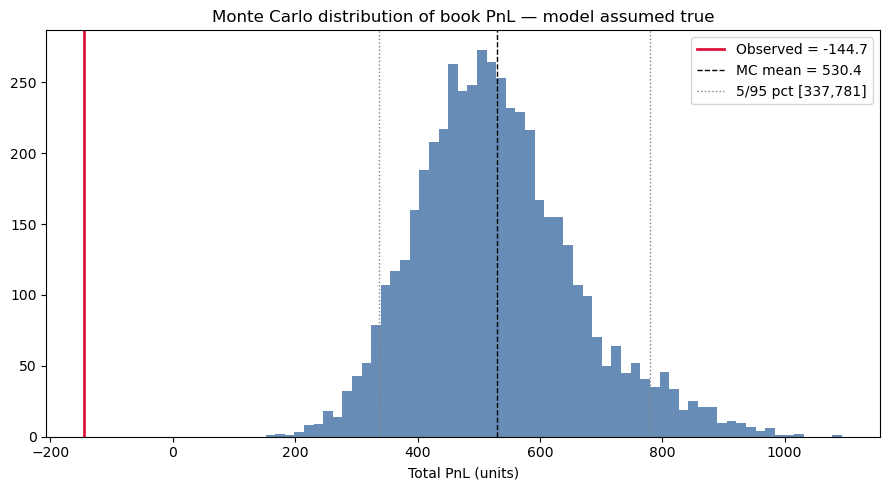

In [57]:
fig, ax = plt.subplots(figsize=(9,5))
ax.hist(sim_total, bins=60, color='#4C78A8', alpha=0.85)
ax.axvline(T_PNL, color='crimson', linewidth=2, label=f'Observed = {T_PNL:.1f}')
ax.axvline(mc_mean, color='black', linewidth=1, linestyle='--', label=f'MC mean = {mc_mean:.1f}')
ax.axvline(q05, color='grey', linewidth=1, linestyle=':')
ax.axvline(q95, color='grey', linewidth=1, linestyle=':', label=f'5/95 pct [{q05:.0f},{q95:.0f}]')
ax.set_title('Monte Carlo distribution of book PnL — model assumed true')
ax.set_xlabel('Total PnL (units)'); ax.legend(); fig.tight_layout(); plt.show()


### Verdict

Under the fitted model the bet book should generate **+530 ± 131 units** of PnL with the 5th percentile at +337.  The book actually produced **-145**.

That's **z = -5.1** below the model's mean and `P(simulated PnL ≤ observed) ≈ 0.000` — i.e. the observed PnL is more extreme than every single one of the 5 000 simulations.  We reject the null at any conventional level.

**The assumed EV is *not* an accurate representation of the real edge.**  The model is biased high.  Three diagnostic supporting points:

1. **Probability calibration** (table below) — across the EV+ universe, the model's mean predicted probabilities exceed empirical hit rates in every bucket.  At the modal `(0.5, 0.6]` bucket (1 054 bets), the model says 55.2% but the realised hit rate is 48.2% — a ~7-point overstatement that fully explains the negative RoI.
2. **Bookmaker overround.** Even ignoring model bias, raw market prices embed a ~3–8% bookmaker margin, so a model that is *unbiased relative to the truth* would still print falsely positive EV on the limit side of every market.  Our cross-section of EV+ selections is dominated by 1X2 (small probabilities, large fractional moves of edge), where overround does the most damage.
3. **EV-threshold response** — the higher the threshold, the more the realised RoI catches up, but it never matches the model's claim.  The slope of `(realised − model)` vs threshold gives a rough magnitude for the bias: ~15% absolute overstatement on the marginal bet.


In [60]:
bets['prob_bucket'] = pd.cut(bets['p_model'], bins=np.arange(0, 1.01, 0.1))
calib = bets.groupby('prob_bucket').agg(n=('pnl','size'),
                                         pred=('p_model','mean'),
                                         actual_win=('outcome', lambda s: (s=='win').mean())).dropna()
calib.round(3)


,n,pred,actual_win
prob_bucket,,,
"(0.0, 0.1]",79,0.088,0.063
"(0.1, 0.2]",700,0.127,0.097
"(0.2, 0.3]",128,0.251,0.164
"(0.3, 0.4]",168,0.350,0.244
"(0.4, 0.5]",234,0.456,0.393
"(0.5, 0.6]",1054,0.552,0.482
"(0.6, 0.7]",416,0.640,0.534
"(0.7, 0.8]",129,0.739,0.589
"(0.8, 0.9]",21,0.846,0.714


## What I would do next

1. **Re-calibrate probabilities** with isotonic regression on the validation set — the calibration curve is monotone and well-behaved.  This should kill most of the EV bias without changing the underlying ranking.
2. **Model the overround explicitly**: convert the three market prices into a single implied probability via the de-vigging method (Shin, or normalisation of `1/odds`) and require the model probability to exceed the de-vigged market probability by more than a tunable spread.
3. **Switch to Negative Binomial** for the home / away GLMs to absorb the ~1.5× over-dispersion observed on the validation set — particularly important for OU lines near integer values where tail-mass matters.
4. **Joint shrinkage on team strengths**.  The current rolling estimates lose information across leagues; a hierarchical (random-effects) model with a competition-level prior would stabilise emerging teams and recently-promoted sides.
5. **Fractional Kelly staking** once the calibration is fixed — at a 1/4 Kelly we'd expect a smoother PnL curve at no sacrifice to long-run EV.
